Electronic Health Records - MIMIC-III - Heart Failure

=========================



#### Loading libraries



In [1]:
library(dplyr)
library(tidyr)
library(tibble)
library(lubridate)
library(readr)
library(stringr)
library(ggplot2)
library(data.table)
library(odbc)
library(RMariaDB)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



Attaching package: ‘lubridate’


The following objects are masked from ‘package:base’:

    date, intersect, setdiff, union



Attaching package: ‘data.table’


The following objects are masked from ‘package:lubridate’:

    hour, isoweek, mday, minute, month, quarter, second, wday, week,
    yday, year


The following objects are masked from ‘package:dplyr’:

    between, first, last




#### Connecting to the database



In [2]:
# Get the credentials file
# It looks like:
################
#username=your.user.name
#password=your.password.assigned
################
creds_file = "creds.txt"

In [3]:
# Set the username and password
creds <- readLines(creds_file)
cred_list <- setNames(
  sub(".*=", "", creds),
  sub("=.*", "", creds)
)

In [4]:
con <- dbConnect(
  drv = RMariaDB::MariaDB(),
  username = cred_list[["username"]],
  password = cred_list[["password"]],
  host = "ehr3.deim.urv.cat",
  dbname = "mimiciiiv14",
  port = 3306
)

### Heart Failure: Comorbidities

In the practice of medicine one of the factors that we need to always consider is the presence of comorbidities, **diseases that are co-ocurring at the same time than a primary condition**. We will explore this concept studying a specific disease, heart failure. This disease has a large prevalence in the U.S. and it&rsquo;s present in the corner&rsquo;s reports of almost 13% of the deaths. Here, we  provide a table with the following information:

-   `ICD9_CODE`: The ICD of the disease
-   `LONG_TITLE`: Long description of the codified disease
-   `N`: Number of patients with that disease associated. We consider only those diseases that are present on admissions where the primary condition is heart failure (ICD9 starting with 428)
-   `Prevalence`: Prevalence of that disease on the heart failure population (in percentage)

We order the results by **`Prevalence` in descending order**



In [ ]:
dbExecute(con, "SET SQL_BIG_SELECTS=1")

sql <- "
/*
 * We want to see what other diseases people have when they are
 * admitted with heart failure.
 * Heart failure is coded as ICD9 codes that start with 428
 * Comorbidities are all the other diseases they have during the same admission.
 */

WITH heart_failure_admissions AS (
    /* First, find all hospital admissions where heart failure was
     * the main reason for coming in SEQ_NUM = 1 means it is the
     * primary diagnosis, the main problem
    */
    SELECT DISTINCT HADM_ID
    FROM DIAGNOSES_ICD
    WHERE ICD9_CODE LIKE '428%'
        AND SEQ_NUM = 1
),
comorbidities AS (
    /* Now look at all the diseases primary and secondary in those
     * heart failure admissions
     * This includes the heart failure itself and everything else they have
     */
    SELECT 
        d.ICD9_CODE
        ,di.LONG_TITLE
        ,d.SUBJECT_ID
    FROM DIAGNOSES_ICD d
    INNER JOIN D_ICD_DIAGNOSES di ON d.ICD9_CODE = di.ICD9_CODE
    INNER JOIN heart_failure_admissions hfa ON d.HADM_ID = hfa.HADM_ID

),
total_hf_patients AS (
	/* We are getting all diagnoses from these admissions, 
     * not just the primary one.
	 * Count how many unique patients have heart failure as primary diagnosis.
     */
    SELECT COUNT(DISTINCT d.SUBJECT_ID) AS total_patients
    FROM DIAGNOSES_ICD d
    INNER JOIN heart_failure_admissions hfa ON d.HADM_ID = hfa.HADM_ID
)
-- Final output
SELECT 
    c.ICD9_CODE
    ,c.LONG_TITLE
    ,COUNT(DISTINCT c.SUBJECT_ID) AS N
    ,ROUND(100.0 * COUNT(DISTINCT c.SUBJECT_ID) / thp.total_patients, 2) AS Prevalence
FROM comorbidities c
CROSS JOIN total_hf_patients thp
GROUP BY c.ICD9_CODE, c.LONG_TITLE, thp.total_patients
ORDER BY Prevalence DESC;
"

In [ ]:
dbGetQuery(con, sql) %>% head(30)

After reading the official Heart Disease Facts from CDC website and other related pages [available here](https://www.cdc.gov/heart-disease/data-research/facts-stats/index.html), and looking the results above in the last output, we find some clinical patterns.

For example, related with `heart failure comorbidities`, the **Hypertension**, is 32% prevalent, whereas CDC notes this is a major risk factor. In fact, he hypertension is one of the most common conditions leading to heart failue. Other interconnected is hypertensive chronic kidney disease.

The **Coronary artery disease** is ~36%, the major cause of heart failue.
The **Diabetes** is ~29%; the **Kidney disease**, various combined codes, is ~52%, CDD emphasizes the heart and kidney connection;the  **Atrial fibrillation**, is ~ 53%, is very common with heart failure.

The most prevalent comorbidities in the analysis above, match the conditions the CDC identifies as commonly associated with heart failure.



Pitfall:

We included all diagnoses from the admission, which means heart failure itself is counted as comorbidity, the prevalence is around 100%. Checking the ICD9 codes some of heart failure are related and there are all variations of heart failure. The code starting with 428, not separate comorbidities. Others, like kidney failure, respiratory failure, urinary tract infection and pneumonia, are developed during the hospitalization as complications, not pre-existing conditions. So, after excluding all heart failures as primary conditions, the second step is split the the results if the condition appears in previous admission, filter by conditions with LIKE %acute% for example, and count only conditions in multiple admissions, to confirm they are chronic.

Other pitfall in the analysis, is the query includes treatment and procedures instead of disease. We saw long-term use of anticoagulants, aortocoronoray bypass status, angioplasty status and long-term use of insuline. For example, V-codes, as mentioned in the [official list of ICD-9 codes](https://bioportal.bioontology.org/ontologies/ICD9CM), are classified as external causes of injury and supplemental classification.

There are the same disease, named by CKD coded three different ways. Usually there are triple-counting patients. The best solution is group related codes into disease categories.

Other point of view, we can't tell if hypertension caused heart failure or resulted from it. This matters for understanding disease progression and prevention. The solution to apply in the analysis, is track when conditions were first diagnosed relative to first heart failure diagnosis, which splits pre-existing and concurrent diagnosis.

Another best approach to adopt in the analysis, we only see diagnoses recorded during HF admissions. If a patient had well-controlled diabetes diagnosed years ago but it's not mentioned in the heart failure admission, example it wasn't immediately relevant, we miss it and we haven't more relevant information about it. The solution is examine the entire patient medical history across all admissions.

### Heart Failure: Building a cohort

We will build a **cohort of patients diagnosed with a HF as primary condition**. From each patient, we obtain some important clinical and demographic features. The resulting table contains:

-   `SUBJECT_ID`
-   `GENDER`
-   `AGE_FIRST`: age at the first diagnosis of heart failure
-   `AGE_LAST`: age at the last diagnosis of heart failure
-   `ETHNICITY`
-   `DECEASED`: 1 if the patient has died 0 otherwise
-   `AVG_LOS`: Average length-of-stay
-   `DM2`: 1 if the patient has been diagnosed with diabetes mellitus type II, 0 otherwise
-   `CAD`: 1 if the patient has been diagnosed with coronary artery disease, 0 otherwise
-   `CKD`: 1 if the patient has been diagnosed with cronic kidney disease, 0 otherwise
-   `HYPERTENSION`: 1 if the patient has been diagnosed with hypertension, 0 otherwise
    
    The results must be ordered by age **at the last admision in descending order**.



In [13]:
dbExecute(con, "SET SQL_BIG_SELECTS=1")
sql <- "
/*
 * We're building a complete profile of heart failure patients.
 * This includes the demographics data, outcomes,
 * and what other diseases they have comorbidities.
 */

WITH hf_patients AS (
    /*
     * First, let's identify all patients who had heart failure
     * as their main diagnosis at least once
     */
	SELECT DISTINCT d.SUBJECT_ID
    FROM DIAGNOSES_ICD d
    WHERE d.ICD9_CODE LIKE '428%'
        AND d.SEQ_NUM = 1
),

hf_admissions AS (
	-- Get all the admissions for these heart failure patients
    SELECT 
        d.SUBJECT_ID
        ,d.HADM_ID
        ,a.ADMITTIME
        ,a.DISCHTIME
        ,a.ETHNICITY
        ,DATEDIFF(a.DISCHTIME, a.ADMITTIME) AS LOS
    FROM DIAGNOSES_ICD d
    INNER JOIN ADMISSIONS a ON d.HADM_ID = a.HADM_ID
    WHERE d.ICD9_CODE LIKE '428%'
    AND d.SEQ_NUM = 1
),

age_info AS (
	/*Calculate age at first and last HF diagnosis for each patient.
	 * Accordingly with MIMIC-IV v3.1, date and times were shifted randomly
	 * into the future using an offset measured in days. For that, the age
	 * is not exactly due the shifting calculation applied.
	 */
    SELECT 
        ha.SUBJECT_ID
        ,ha.ADMITTIME
        ,YEAR(MIN(ha.ADMITTIME)) - YEAR(p.DOB) AS AGE_FIRST
        ,YEAR(MAX(ha.ADMITTIME)) - YEAR(p.DOB) AS AGE_LAST
    FROM hf_admissions ha
    INNER JOIN PATIENTS p ON ha.SUBJECT_ID = p.SUBJECT_ID
    GROUP BY ha.SUBJECT_ID, p.DOB
),
avg_los AS (
    -- Calculate average length of stay for each
    -- patient across all their HF admissions.
	SELECT 
        SUBJECT_ID
        ,ROUND(AVG(LOS), 1) AS AVG_LOS
    FROM hf_admissions
    GROUP BY SUBJECT_ID
),
diabetes AS (
	-- Check for comorbidities, for diabetes 
	-- type 2 which codes starting with 250
    SELECT DISTINCT d.SUBJECT_ID
    FROM DIAGNOSES_ICD d
    INNER JOIN hf_patients hp ON d.SUBJECT_ID = hp.SUBJECT_ID
    WHERE d.ICD9_CODE LIKE '250%'
),
cad AS (
	-- Coronary artery disease which codes starting with 414
    SELECT DISTINCT d.SUBJECT_ID
    FROM DIAGNOSES_ICD d
    INNER JOIN hf_patients hp ON d.SUBJECT_ID = hp.SUBJECT_ID
    WHERE d.ICD9_CODE LIKE '414%'
),
ckd AS (
	-- Chronic kidney disease which codes starting with 585.
    SELECT DISTINCT d.SUBJECT_ID
    FROM DIAGNOSES_ICD d
    INNER JOIN hf_patients hp ON d.SUBJECT_ID = hp.SUBJECT_ID
    WHERE d.ICD9_CODE LIKE '585%'
),
hypertension AS (
	-- Hypertension which codes starting with 401.
    SELECT DISTINCT d.SUBJECT_ID
    FROM DIAGNOSES_ICD d
    INNER JOIN hf_patients hp ON d.SUBJECT_ID = hp.SUBJECT_ID
    WHERE d.ICD9_CODE LIKE '401%'
)
-- Final output
-- It's ordered by desc last admission
SELECT 
    hp.SUBJECT_ID
    ,p.GENDER
    ,ai.AGE_FIRST
    ,ai.AGE_LAST
    ,(SELECT ETHNICITY 
     FROM hf_admissions 
     WHERE SUBJECT_ID = hp.SUBJECT_ID 
     LIMIT 1) AS ETHNICITY

    ,CASE WHEN p.DOD IS NOT NULL THEN 1 ELSE 0 END AS DECEASED
    ,al.AVG_LOS
    ,CASE WHEN dm.SUBJECT_ID IS NOT NULL THEN 1 ELSE 0 END AS DM2
    ,CASE WHEN c.SUBJECT_ID IS NOT NULL THEN 1 ELSE 0 END AS CAD
    ,CASE WHEN ck.SUBJECT_ID IS NOT NULL THEN 1 ELSE 0 END AS CKD
    ,CASE WHEN h.SUBJECT_ID IS NOT NULL THEN 1 ELSE 0 END AS HYPERTENSION
FROM hf_patients hp
INNER JOIN PATIENTS p ON hp.SUBJECT_ID = p.SUBJECT_ID
INNER JOIN age_info ai ON hp.SUBJECT_ID = ai.SUBJECT_ID
INNER JOIN avg_los al ON hp.SUBJECT_ID = al.SUBJECT_ID
LEFT JOIN diabetes dm ON hp.SUBJECT_ID = dm.SUBJECT_ID
LEFT JOIN cad c ON hp.SUBJECT_ID = c.SUBJECT_ID
LEFT JOIN ckd ck ON hp.SUBJECT_ID = ck.SUBJECT_ID
LEFT JOIN hypertension h ON hp.SUBJECT_ID = h.SUBJECT_ID
ORDER BY ai.ADMITTIME DESC;
"

[1] 0

In [14]:

hf_cohort <- dbGetQuery(con, sql) # Save the output in a data frame for later use
hf_cohort %>% head(30)

,SUBJECT_ID,GENDER,AGE_FIRST,AGE_LAST,ETHNICITY,DECEASED,AVG_LOS,DM2,CAD,CKD,HYPERTENSION
,<int>,<chr>,<int>,<int>,<chr>,<int>,<dbl>,<int>,<int>,<int>,<int>
1,5196,M,307,307,ASIAN,0,12.0,1,1,1,1
2,18250,F,73,74,BLACK/AFRICAN AMERICAN,1,2.5,0,1,0,1
3,21458,F,53,53,BLACK/AFRICAN AMERICAN,1,10.0,0,0,1,0
4,21900,F,59,62,WHITE,0,4.7,0,1,1,1
5,42820,F,74,75,WHITE,0,6.7,1,1,0,1
6,29690,F,69,69,BLACK/AFRICAN AMERICAN,1,9.0,1,1,1,0
7,78966,F,85,85,HISPANIC/LATINO - PUERTO RICAN,0,13.0,1,1,1,0
8,2224,M,83,83,WHITE,1,21.0,0,1,0,1
9,12920,F,74,74,ASIAN,1,18.0,1,1,0,1


## Regular expressions

In this section, we will work with **regular expressions**. The first exercises will be conducted over a single medical report. We first connect to MIMIC-III and extract the TEXT field from the NOTEEVENTS table corresponding to the only register with `SUBJECT_ID` equal to `13702`, `CATEGORY` equal to &rsquo;Discharge summary&rsquo;, and `CHARTDATE` equal to &rsquo;2118-06-14&rsquo;. Store it in a string variable called `text`.



In [15]:
sql_diagnosis_all <- "
SELECT TEXT
FROM NOTEEVENTS
WHERE SUBJECT_ID = 13702
  AND CATEGORY = 'Discharge summary'
  AND CHARTDATE = '2118-06-14'
"

diagnosis_all <- dbGetQuery(con, sql_diagnosis_all)
text <- diagnosis_all$TEXT[1]

In [16]:
# DO NOT MODIFY THIS CELL
writeLines(str_c('<', text ,'>'))

<Admission Date:  [**2118-6-2**]       Discharge Date:  [**2118-6-14**]

Date of Birth:                    Sex:  F

Service:  MICU and then to [**Doctor Last Name **] Medicine

HISTORY OF PRESENT ILLNESS:  This is an 81-year-old female
with a history of emphysema (not on home O2), who presents
with three days of shortness of breath thought by her primary
care doctor to be a COPD flare.  Two days prior to admission,
she was started on a prednisone taper and one day prior to
admission she required oxygen at home in order to maintain
oxygen saturation greater than 90%.  She has also been on
levofloxacin and nebulizers, and was not getting better, and
presented to the [**Hospital1 18**] Emergency Room.

In the [**Hospital3 **] Emergency Room, her oxygen saturation was
100% on CPAP.  She was not able to be weaned off of this
despite nebulizer treatment and Solu-Medrol 125 mg IV x2.

Review of systems is negative for the following:  Fevers,
chills, nausea, vomiting, night sweats, change in w

### Medications

In `text`, there is a paragraph with the **list of medications** on admission. Using `stringr` functions, **extract it to a list of strings called `medications_admission`**. Remove the enumeration in front of each medication. Each string in the list **must be composed by the name of the medication and its dosage** just as it appears in the report.



In [ ]:

#find the paragraph of medications
med_block <- str_extract(
  text,
  regex(
    "Medications on Admission:[\\s\\S]*?(?=\\n\\n[A-Z ])",
    ignore_case = TRUE
  )
)
med_block

#extract list of strings
medications_admission <- str_extract_all(
  med_block,
    "\\n\\s*\\d+\\.\\s*[^\\n]+"
)[[1]]

#remove enumeration
medications_admission <- str_remove(
  medications_admission,
  "^\\n\\s*\\d+\\.\\s*"
)


[1] "MEDICATIONS ON ADMISSION:\n1. Hydrochlorothiazide 25 q.d.\n2. Prednisone 60 mg, 50 mg, 40 mg, 20 mg.\n3. Levofloxacin 500 mg q.d.\n4. Imdur 60 mg q.d.\n5. Synthroid 75 mcg q.d.\n6. Pulmicort nebulizer b.i.d.\n7. Albuterol nebulizer q.4. prn.\n8. Lexapro 10 mg q.d.\n9. Protonix 40 mg q.d.\n10. Aspirin 81 mg q.d."

In [ ]:

medications_admission

[1] "Hydrochlorothiazide 25 q.d."           
 [2] "Prednisone 60 mg, 50 mg, 40 mg, 20 mg."
 [3] "Levofloxacin 500 mg q.d."              
 [4] "Imdur 60 mg q.d."                      
 [5] "Synthroid 75 mcg q.d."                 
 [6] "Pulmicort nebulizer b.i.d."            
 [7] "Albuterol nebulizer q.4. prn."         
 [8] "Lexapro 10 mg q.d."                    
 [9] "Protonix 40 mg q.d."                   
[10] "Aspirin 81 mg q.d."

### Medications data frame

Now that we have extracted the medication information, we **put this information in a structured object**. Specifically, we generate a data.frame `medications` with the following columns, using regular expressions to segment the previously generated strings:

-   `medication`: name of the product
-   `dosage`: numerical value with the prescribed dosage
-   `units`: units on which the dossage is specified

In [ ]:


# 1) REGEX PATTERNS
# Match a dosage WITH units, e.g. "81 mg", "75 mcg"
dose_unit_pat <- regex(
  "\\b(\\d+(?:\\.\\d+)?)\\s*(mg|mcg|g|kg|ml|mL|iu|IU|units?|%)\\b",
  ignore_case = TRUE
)

# Remove ALL occurrences of dosage+unit from the medication string
dose_unit_remove_pat <- regex(
  "\\b\\d+(?:\\.\\d+)?\\s*(mg|mcg|g|kg|ml|mL|iu|IU|units?|%)\\b\\s*[\\.,]?",
  ignore_case = TRUE
)

# Match frequency expressions (many variants)
# Examples:
#   q.d, qd, q.d.
#   b.i.d, bid
#   q.4., q4h
#   prn, p.r.n.
freq_pat <- regex(
  paste(
    "\\b(?:",
    "q\\s*\\.?\\s*d\\.?|qd\\b",                          # once daily
    "|b\\s*\\.?\\s*i\\s*\\.?\\s*d\\.?|bid\\b",           # twice daily
    "|t\\s*\\.?\\s*i\\s*\\.?\\s*d\\.?|tid\\b",           # three times daily
    "|q\\s*\\.?\\s*i\\s*\\.?\\s*d\\.?|qid\\b",           # four times daily
    "|q\\s*\\.?\\s*\\d+\\s*\\.?\\s*(?:h|hr|hrs)?\\.?\\b",# q.4., q4h, q 4 h
    "|p\\s*\\.?\\s*r\\s*\\.?\\s*n\\.?|prn\\b",           # PRN
    ")(?:\\.)?",
    sep = ""
  ),
  ignore_case = TRUE
)

# Match a dosage WITHOUT units (followed by a frequency)
# (e.g. "Hydrochlorothiazide 25 q.d.")
dose_only_pat <- regex(
  paste(
    "\\b(\\d+(?:\\.\\d+)?)\\b(?=\\s*(?:",
    "q\\s*\\.?\\s*d\\.?|qd\\b|",
    "b\\s*\\.?\\s*i\\s*\\.?\\s*d\\.?|bid\\b|",
    "t\\s*\\.?\\s*i\\s*\\.?\\s*d\\.?|tid\\b|",
    "q\\s*\\.?\\s*i\\s*\\.?\\s*d\\.?|qid\\b|",
    "q\\s*\\.?\\s*\\d+\\s*\\.?\\s*(?:h|hr|hrs)?\\.?\\b|",
    "p\\s*\\.?\\s*r\\s*\\.?\\s*n\\.?|prn\\b",
    ")\\b|\\s*$)",
    sep = ""
  ),
  ignore_case = TRUE
)


# 2) EXTRACT DOSAGE + UNITS
# First try to extract dosage WITH units
m1 <- str_match(medications_admission, dose_unit_pat)

dosage <- suppressWarnings(as.numeric(m1[, 2]))  # numeric dosage
units  <- m1[, 3]                                # units (mg, mcg, ...)

# 3) FALLBACK: DOSAGE ONLY
# If no units were found, try extracting a bare number
need_only <- is.na(dosage)

m2 <- str_match(medications_admission, dose_only_pat)

dosage[need_only] <- suppressWarnings(as.numeric(m2[need_only, 2]))
units[need_only]  <- NA_character_


# 4) CLEAN MEDICATION NAME
medication <- medications_admission |>
  # remove all "XX mg" chunks
  str_remove_all(dose_unit_remove_pat) |>
  # remove frequency expressions (q.d., b.i.d., q.4., prn, ...)
  str_remove_all(freq_pat) |>
  # clean commas and extra whitespace
  str_replace_all("\\s*,\\s*", " ") |>
  str_replace_all("\\s+", " ") |>
  # remove trailing punctuation
  str_replace_all("[\\.,;:]\\s*$", "") |>
  str_trim()

# If dosage was extracted without units,
# remove the bare number from the medication name
medication[need_only] <- medication[need_only] |>
  str_remove_all(regex("\\b\\d+(?:\\.\\d+)?\\b")) |>
  str_replace_all("\\s+", " ") |>
  str_trim()

# 5) FINAL DATA FRAME
medications <- data.frame(
  medication = medication,
  dosage     = dosage,
  units      = units,
  stringsAsFactors = FALSE
)


In [ ]:

print(medications)

            medication dosage units
1  Hydrochlorothiazide     25  <NA>
2           Prednisone     60    mg
3         Levofloxacin    500    mg
4                Imdur     60    mg
5            Synthroid     75   mcg
6  Pulmicort nebulizer     NA  <NA>
7  Albuterol nebulizer     NA  <NA>
8              Lexapro     10    mg
9             Protonix     40    mg
10             Aspirin     81    mg




This approach works well for common, simple formats but fails on more complex or uncommon ones.
It works well for:
* single doses with units (e.g. Aspirin 81 mg q.d.)
* Doses without units if a clear frequency is present (e.g. Hydrochlorothiazide 25 q.d. → dosage = 25, units = NA)
* Entries without any dose (e.g. Pulmicort nebulizer) → dosage and units set to NA

Failures:
* Multiple doses in one line (e.g. prednisone tapers): only the first dose is kept, the rest are discarded.
* Dose ranges or complex expressions (e.g. 5–10 mg, 2.5 mg/3 mL): only partial information is extracted.
* Unrecognized units or frequencies: if not covered by the regex, they may be missed or remain in the medication field.
* Medication names containing numbers (e.g. Vitamin B12): can be misinterpreted in rare edge cases.

Handling missing or multiple values:
* Missing dosage or units are stored as NA.
* Multiple dosages are reduced to a single (first) dose, causing information loss.

Overall, the method is precise for standard formats, but loses information in complex or non-standard medication descriptions.

Medications are already stored on an structured table in MIMIC-III. Compare the results obtained in this exercise with the ones stored for this particular admission in MIMIC-III:


In [27]:
sql <- "
WITH admission AS (
  SELECT n.HADM_ID
  FROM NOTEEVENTS n
  WHERE n.SUBJECT_ID = 13702
    AND n.CATEGORY = 'Discharge summary'
    AND n.CHARTDATE = '2118-06-14'
)
SELECT
  p.HADM_ID,
  p.STARTDATE,
  p.ENDDATE,
  p.DRUG,
  p.DRUG_NAME_POE,
  p.DRUG_NAME_GENERIC,
  p.DOSE_VAL_RX,
  p.DOSE_UNIT_RX,
  p.FORM_VAL_DISP,
  p.FORM_UNIT_DISP,
  p.ROUTE,
  p.PROD_STRENGTH
FROM PRESCRIPTIONS p
JOIN admission a
  ON p.HADM_ID = a.HADM_ID
WHERE p.SUBJECT_ID = 13702
ORDER BY p.STARTDATE, p.DRUG;
"

dbGetQuery(con, sql)


HADM_ID,STARTDATE,ENDDATE,DRUG,DRUG_NAME_POE,DRUG_NAME_GENERIC,DOSE_VAL_RX,DOSE_UNIT_RX,FORM_VAL_DISP,FORM_UNIT_DISP,ROUTE,PROD_STRENGTH
<int>,<dttm>,<dttm>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
107527,2118-06-02,2118-06-03,Albuterol Neb Soln,Albuterol Neb Soln,Albuterol Neb Soln,1,NEB,1,VIAL,IH,0.083%;3mL Vial
107527,2118-06-02,2118-06-14,Aspirin,Aspirin,Aspirin,81,mg,1,TAB,PO,81mg Tab
107527,2118-06-02,2118-06-14,Escitalopram Oxalate,Escitalopram Oxalate,Escitalopram Oxalate,10,mg,1,TAB,PO,10mg Tablet
107527,2118-06-02,2118-06-05,Heparin,Heparin,Heparin Sodium,5000,UNIT,1,ml,SC,5000U/ML VIAL
107527,2118-06-02,2118-06-04,Insulin,Insulin,Insulin,0,UNIT,0,VIAL,SC,Dummy Pkg for POE pump and PHA SS ordering
107527,2118-06-02,2118-06-03,Ipratropium Bromide Neb,Ipratropium Bromide Neb,Ipratropium Bromide Neb,1,NEB,1,VIAL,IH,2.5ml Vial
107527,2118-06-02,2118-06-08,Isosorbide Mononitrate (Extended Release),Isosorbide Mononitrate (Extended Release),Isosorbide Mononitrate (Extended Release),60,mg,1,TAB,PO,60mg ER tab
107527,2118-06-02,2118-06-08,Levofloxacin,Levofloxacin,Levofloxacin,500,mg,1,TAB,PO,500mg Tab
107527,2118-06-02,2118-06-14,Levothyroxine Sodium,Levothyroxine Sodium,Levothyroxine Sodium,75,mcg,1,TAB,PO,75mcg Tab


The **ejection fraction measures the volumetric fraction of fluid ejected from a chamber with each contraction**. This metric is deeply connected with the heart functionality. Doctors typically measure the ejection fraction **using an echocardiogram**, which is an ultrasound imaging test that uses sound waves to create a picture of the heart. The test allows the doctor to see the size and shape of the heart and how well it is functioning. Doctors can measure both, the volume of blood in the left ventricle and in the right ventricle. In general, the **left ventricle is responsible for pumping oxygenated blood to the rest of the body**, while the right ventricle pumps blood to the lungs to be oxygenated.

It turns out that **left ventricular ejection fraction (LVEF) is closely related with the diagnosis of heart failure** since it can be used to further **classify the disease**. According to the European Society of Cardiology those can be:

-   Heart failure with preserved LVEF (HFpEF) [LVEF > 50%]
-   Heart failure with moderated reduced LVEF (HFmrEF) [41% < LVEF < 50%]
-   Heart failure with reduced LVEF (HFrEF) [LVEF < 41%]

**Treatment for these types of heart failure may differ**, depending on the underlying cause and the specific symptoms a person is experiencing. In general, managing heart failure involves a combination of medications, lifestyle changes, and in some cases, medical procedures or surgeries.



### Heart Failure: Ejection Fraction

We **extract using regular expressions the LVEF from the `NOTEEVENTS`** using the echocardiogram reports associated with admissions where the primary diagnosis is heart failure. There are **many different ways how this information can be recorded** (LV ejection fraction, LVEF, L.V.E.F&#x2026;). **We analyze those different scenarios** when we design the extraction strategy. We provide a data frame with the following content:

-   `HADM_ID`: admission number
-   `LVEF`: Left ventricular ejection fraction (if there are more than one measurement per admission you must provide the average)


In [ ]:


# Find ICD_9 codes corresponding to Heart failure:

sql <- "
SELECT did.ICD9_CODE ,did.SHORT_TITLE , did.LONG_TITLE
FROM D_ICD_DIAGNOSES did
where lower(did.SHORT_TITLE)  like '%heart f%';
"

dbGetQuery(con, sql)

ICD9_CODE,SHORT_TITLE,LONG_TITLE
<chr>,<chr>,<chr>
39891,Rheumatic heart failure,Rheumatic heart failure (congestive)
4281,Left heart failure,Left heart failure
4289,Heart failure NOS,"Heart failure, unspecified"


In [29]:

dbExecute(con, "SET SQL_BIG_SELECTS=1")

sql <- "
/*
    Identify hospital admissions with a primary diagnosis of
    heart failure (using ICD-9 codes identified in the previous
    query), and retrieve all clinical notes (NOTEEVENTS)
    associated with those admissions.
    
    Multiple notes per admission are expected, as LVEF may be
    reported in different documents during the same hospital stay.
 */
WITH admissions_pd_hf AS (
  SELECT DISTINCT SUBJECT_ID, HADM_ID
  FROM DIAGNOSES_ICD
  WHERE SEQ_NUM = 1
    AND ICD9_CODE LIKE '428%' -- IN ('39891','4281','4289') -- Heart failure codes
)
SELECT
  n.SUBJECT_ID,
  n.HADM_ID,
  n.CHARTDATE,
  n.CATEGORY,
  n.TEXT
FROM NOTEEVENTS n
JOIN admissions_pd_hf a
  ON a.HADM_ID = n.HADM_ID;
"
notes_hf <- dbGetQuery(con, sql)
# notes_hf %>% head(1)

[1] 0

In [30]:
pattern_context <- regex(
  "(l\\.?v\\.?e\\.?.?f|\\bejection fraction\\b|\\bef\\b)[^%]{0,100}((?:[<>]=?\\s*)?\\d{1,3}(?:\\s*(?:-)\\s*\\d{1,3})?\\s*%)", 
  ignore_case = TRUE
)
# With this regex we will identifty: lvef, l.v.e.f and ejection fraction as single words, and then searches for a percentage value within the
# next 100 characters. The full matched text (context + value) is returned.
# Ejection fraction is by default left ventricular.

pattern_token <- regex(
  "(?:[<>]=?\\s*)?\\d{1,3}(?:\\s*(?:-)\\s*\\d{1,3})?\\s*%",
  ignore_case = TRUE
)
# This regex extracts only the EF value as a percentage, allowing single values up to 3 digits (40%), ranges (40-45%) and inequality expressions (>55%, <55%, >=55%, <=55%).
values_extracted <- notes_hf %>%
  mutate(
    lvef_context = str_extract(TEXT, pattern_context),
    lvef_value = str_extract(lvef_context, pattern_token),
    lvef_value = str_replace_all(lvef_value, "\\s+", "") # remove spaces
  )

values_extracted %>%
  filter(!is.na(lvef_value)) %>%
  nrow() # Check number of values found

[1] 6985

In [58]:
values_extracted %>% 
  filter(!is.na(lvef_value)) %>%
  arrange(HADM_ID) %>%
  select(HADM_ID, lvef_context, lvef_value) %>% head(10) # Check output obtained

,HADM_ID,lvef_context,lvef_value
,<int>,<chr>,<chr>
1,100050,LVEF 50-55%,50-55%
2,100050,LVEF 50-55%,50-55%
3,100061,LVEF of 55-65%,55-65%
4,100061,LVEF = 25%,25%
5,100136,EF 62%,62%
6,100136,EF 62%,62%
7,100136,LVEF (>55%,>55%
8,100182,EF of 40%,40%
9,100182,EF 40%,40%


In [59]:
values_extracted <- values_extracted %>%
  mutate(
    n1 = as.numeric(str_extract(lvef_value, "\\d{1,3}")), # extract lower range value and convert it to a numeric value
    n2 = suppressWarnings(
      as.numeric(str_match(lvef_value, "[-–](\\d{1,3})%")[,2]) # extract upper range value and convert it to a numeric value
    )
  ) # Manage LVEF value ranges

values_extracted <- values_extracted %>%
  mutate(
    lvef_numeric = if_else( 
      !is.na(n2),
      (n1 + n2) / 2,   # By computing it's mid-point
      n1            
    )
  )

values_extracted %>%
  filter(!is.na(lvef_value)) %>%
  arrange(HADM_ID) %>%
  select(HADM_ID, lvef_context, lvef_value, n1, n2, lvef_numeric)  %>% head(10)

,HADM_ID,lvef_context,lvef_value,n1,n2,lvef_numeric
,<int>,<chr>,<chr>,<dbl>,<dbl>,<dbl>
1,100050,LVEF 50-55%,50-55%,50,55,52.5
2,100050,LVEF 50-55%,50-55%,50,55,52.5
3,100061,LVEF of 55-65%,55-65%,55,65,60.0
4,100061,LVEF = 25%,25%,25,NA,25.0
5,100136,EF 62%,62%,62,NA,62.0
6,100136,EF 62%,62%,62,NA,62.0
7,100136,LVEF (>55%,>55%,55,NA,55.0
8,100182,EF of 40%,40%,40,NA,40.0
9,100182,EF 40%,40%,40,NA,40.0


In [65]:
lvef_by_admission <- values_extracted %>%
  filter(!is.na(lvef_numeric)) %>%
  group_by(HADM_ID) %>%
  summarise(
    LVEF = round(mean(lvef_numeric), 2), # Compute average LVEF for same admission id's, round to 2 decimals
    .groups = "drop"
  ) %>%
  arrange(HADM_ID)

lvef_by_admission %>% head(10)

HADM_ID,LVEF
<int>,<dbl>
100050,52.50
100061,42.50
100136,59.67
100182,40.00
100199,27.50
100209,20.00
100281,55.00
100342,60.00
100343,55.00


### Heart Failure: Adding LVEF to our cohort

In order to understand the relation of ejection fraction with other factors, we **merge the table `hf_cohort` with the data frame containing LVEF values** that we just obtained. If a patient has associated more than one LVEF we will input the average. Additionally, we will **add a new column `type`**, specifying the type of HF (HFrEF, HFmrEF or HFpEF).



In [ ]:


# First we need to add HADM_ID to the hf_cohort table to be able to merge it with lvef information

adm_map <- dbGetQuery(
  con,
  "SELECT DISTINCT HADM_ID, SUBJECT_ID FROM ADMISSIONS"
) 
adm_map %>% head(10)

,HADM_ID,SUBJECT_ID
,<int>,<int>
1,163353,2
2,145834,3
3,185777,4
4,178980,5
5,107064,6
6,118037,7
7,159514,8
8,150750,9
9,184167,10


In [82]:
lvef_type_by_patient <- lvef_by_admission %>%
  left_join(adm_map, by = "HADM_ID") %>% # patient_id with lvef by admission
  group_by(SUBJECT_ID) %>% # group by subject_id to manage patients with more than one admission and compute the average
  summarise(
    LVEF = round(mean(LVEF),2),
    .groups = "drop"
  ) %>%
  mutate(
    type = case_when(
      LVEF < 41 ~ "HFrEF",
      LVEF >= 41 & LVEF < 50 ~ "HFmrEF",
      LVEF >= 50 ~ "HFpEF"
      )
  )

hf_cohort_lvef <- hf_cohort %>%
  left_join(lvef_type_by_patient, by = "SUBJECT_ID")

hf_cohort_lvef %>% head(10)

,SUBJECT_ID,GENDER,AGE_FIRST,AGE_LAST,ETHNICITY,DECEASED,AVG_LOS,DM2,CAD,CKD,HYPERTENSION,LVEF,type
,<int>,<chr>,<int>,<int>,<chr>,<int>,<dbl>,<int>,<int>,<int>,<int>,<dbl>,<chr>
1,5196,M,307,307,ASIAN,0,12.0,1,1,1,1,55.00,HFpEF
2,18250,F,73,74,BLACK/AFRICAN AMERICAN,1,2.5,0,1,0,1,55.00,HFpEF
3,21458,F,53,53,BLACK/AFRICAN AMERICAN,1,10.0,0,0,1,0,55.00,HFpEF
4,21900,F,59,62,WHITE,0,4.7,0,1,1,1,32.08,HFrEF
5,42820,F,74,75,WHITE,0,6.7,1,1,0,1,62.58,HFpEF
6,29690,F,69,69,BLACK/AFRICAN AMERICAN,1,9.0,1,1,1,0,24.44,HFrEF
7,78966,F,85,85,HISPANIC/LATINO - PUERTO RICAN,0,13.0,1,1,1,0,70.00,HFpEF
8,2224,M,83,83,WHITE,1,21.0,0,1,0,1,NA,NA
9,12920,F,74,74,ASIAN,1,18.0,1,1,0,1,55.00,HFpEF


### Heart Failure: LVEF distribution 

The distribution of LVEF values offers a nice description of HF. In this exercise, you must provide a **histogram showing the distribution of those values** (you need to take care of outliers, if there are). Moreover, you need also to show this information **based on gender and by the presence of hypertension**.

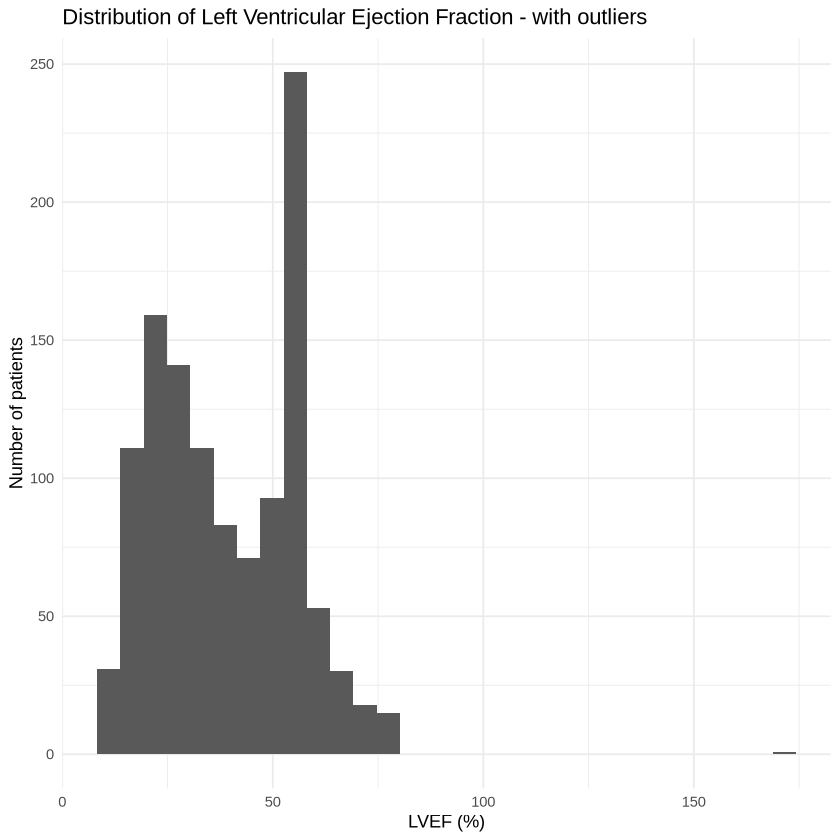

In [102]:
# YOUR CODE GOES HERE!

# Basic histogram without taking outliers in consideration

plt_hf_cohort_lvef <- hf_cohort_lvef %>%
  filter(is.finite(LVEF))

ggplot(plt_hf_cohort_lvef, aes(x = LVEF)) +
  geom_histogram(bins = 30) +
  labs(
    title = "Distribution of Left Ventricular Ejection Fraction - with outliers",
    x = "LVEF (%)",
    y = "Number of patients"
  ) +
  theme_minimal()

# We clearly observe some extreme high values values

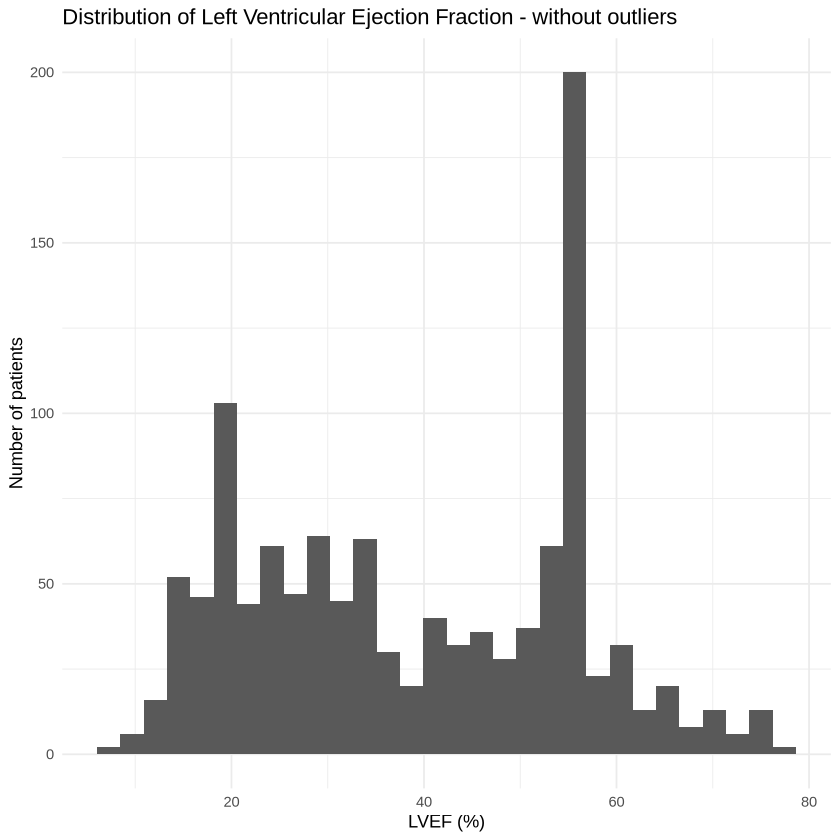

In [103]:
# We will remove outliers using percentiles, excluding values above the upper bound defined by the 95th percentile plus 1.5 times the interquartile range

q <- quantile(plt_hf_cohort_lvef$LVEF, probs = c(0.05, 0.95), na.rm = TRUE)
iqr <- q[2] - q[1]

hf_cohort_lvef_clean <- plt_hf_cohort_lvef %>%
  filter(LVEF <= q[2] + 1.5 * iqr)

ggplot(hf_cohort_lvef_clean, aes(x = LVEF)) +
  geom_histogram(bins = 30) +
  labs(
    title = "Distribution of Left Ventricular Ejection Fraction - without outliers",
    x = "LVEF (%)",
    y = "Number of patients"
  ) +
  theme_minimal()

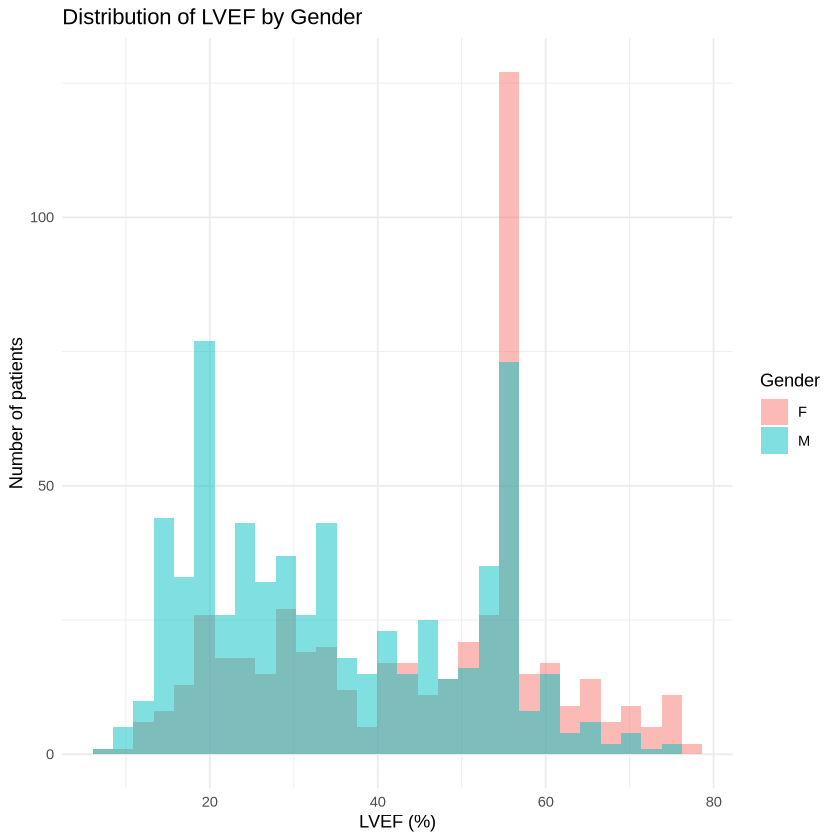

In [104]:
ggplot(hf_cohort_lvef_clean, aes(x = LVEF, fill = GENDER)) +
  geom_histogram(
    bins = 30,
    alpha = 0.5,
    position = "identity"
  ) +
  labs(
    title = "Distribution of LVEF by Gender",
    x = "LVEF (%)",
    y = "Number of patients",
    fill = "Gender"
  ) +
  theme_minimal()

In [105]:
hf_cohort_lvef_clean %>%
  count(GENDER)

# Gender class is slightly inbalanced

GENDER,n
<chr>,<int>
F,510
M,653


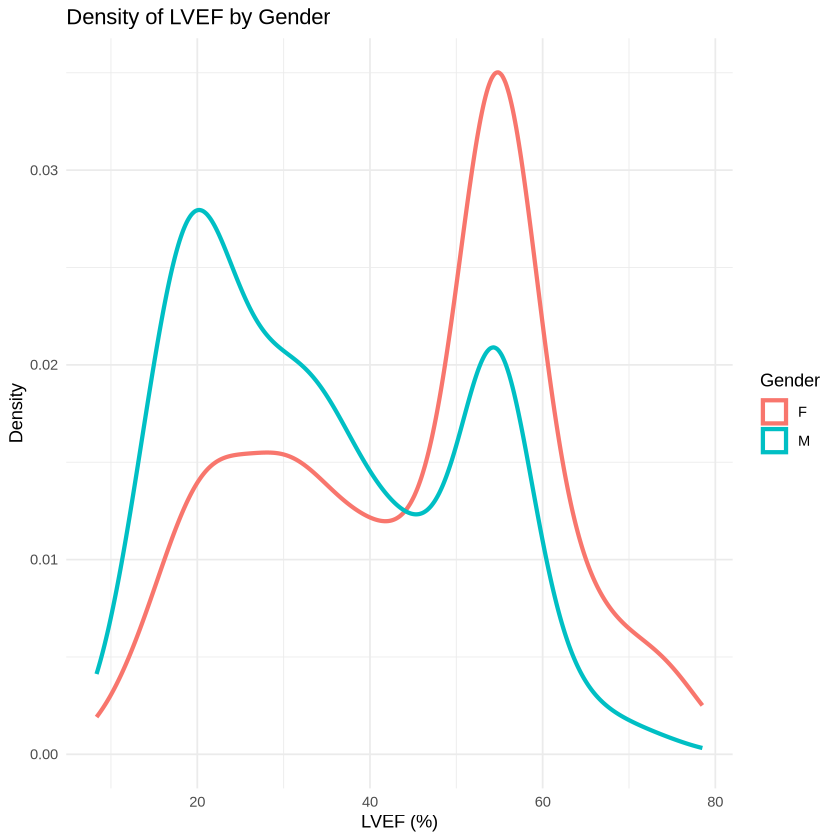

In [106]:
# Plot density to avoid missinterpretations due to inbalanced gender class
ggplot(hf_cohort_lvef_clean, aes(x = LVEF, color = GENDER)) +
  geom_density(linewidth = 1.2) +
  labs(
    title = "Density of LVEF by Gender",
    x = "LVEF (%)",
    y = "Density",
    color = "Gender"
  ) +
  theme_minimal()

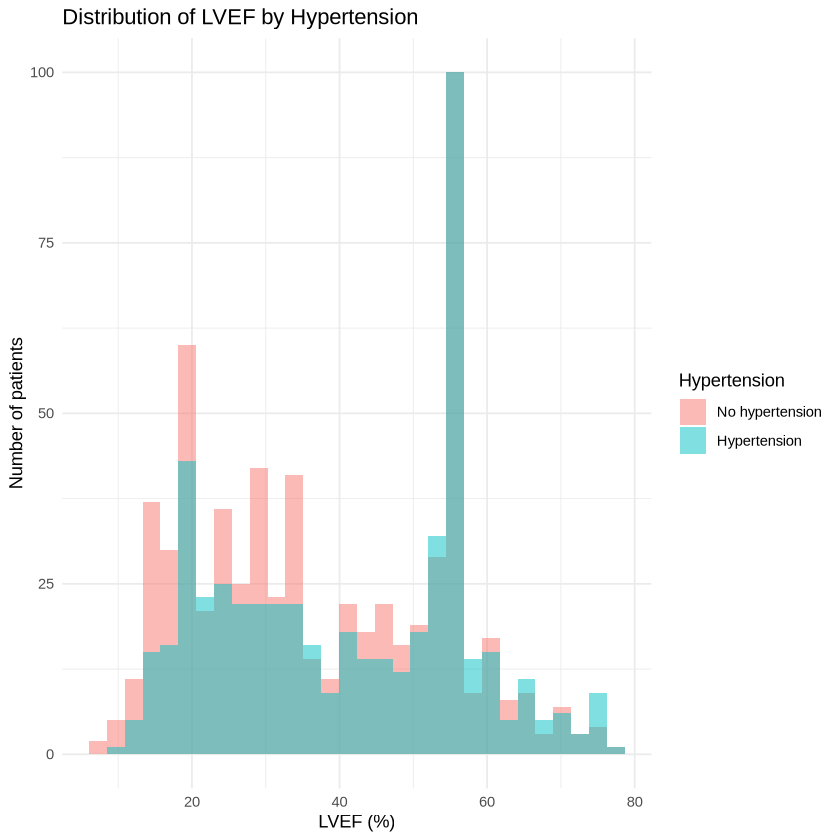

In [107]:
hf_cohort_lvef_clean_ht <- hf_cohort_lvef_clean %>%
  mutate(
    HYPERTENSION_FACTOR = factor(
      HYPERTENSION,
      levels = c(0, 1),
      labels = c("No hypertension", "Hypertension")
    )
  )

ggplot(hf_cohort_lvef_clean_ht, aes(x = LVEF, fill = HYPERTENSION_FACTOR)) +
  geom_histogram(
    bins = 30,
    alpha = 0.5,
    position = "identity"
  ) +
  labs(
    title = "Distribution of LVEF by Hypertension",
    x = "LVEF (%)",
    y = "Number of patients",
    fill = "Hypertension"
  ) +
  theme_minimal()

In [108]:
hf_cohort_lvef_clean_ht %>%
  count(HYPERTENSION_FACTOR)

# Hypertension class is slightly inbalanced

HYPERTENSION_FACTOR,n
<fct>,<int>
No hypertension,645
Hypertension,518


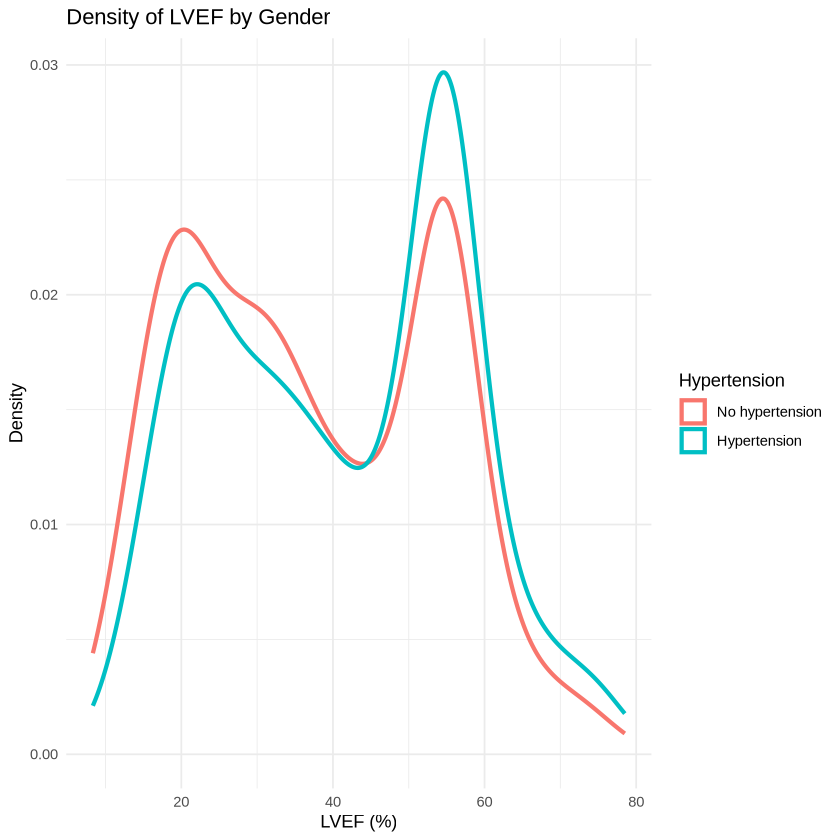

In [109]:
# Plot density to avoid missinterpretations due to inbalanced HT class
ggplot(hf_cohort_lvef_clean_ht, aes(x = LVEF, color = HYPERTENSION_FACTOR)) +
  geom_density(linewidth = 1.2) +
  labs(
    title = "Density of LVEF by Gender",
    x = "LVEF (%)",
    y = "Density",
    color = "Hypertension"
  ) +
  theme_minimal()